## Running original experiment

In [5]:
import csv
from pathlib import Path
from algorithm import machine_learning_algorithm
CSV_PATH = Path('./output/csv/gsb.csv')
rf_runner = machine_learning_algorithm('RF')
nb_runner = machine_learning_algorithm('NB')
dt_runner = machine_learning_algorithm("DT")
knn_runner = machine_learning_algorithm("KNN")

with open(CSV_PATH, 'r', newline='') as csv_file:
    reader = csv.reader(csv_file)
    header = next(reader)
feature_names = header[:-1]

print('Random Forest model:', type(rf_runner.model).__name__)
print('Naive Bayes model   :', type(nb_runner.model).__name__)
print('Decision Tree model :', type(dt_runner.model).__name__)
print('K-Nearest Neighbors model :', type(knn_runner.model).__name__)
print('Training file       :', rf_runner.train_data_name)

initializing


2026-05-04 12:00:24,602 - DEBUG - gsb.csv caused an error during training
2026-05-04 12:00:24,604 - ERROR - Error : Traceback (most recent call last):
  File "/home/ubuntu/Desktop/Phishing-Detection-Engine/predictors/algorithm.py", line 91, in preparing_train_data
    with open("{0}{1}".format(self.path_output_csv, file_name), "r", newline="") as csv_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '../output/csv/gsb.csv'



ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [2]:
rf_scores = rf_runner.accuracy()
nb_scores = nb_runner.accuracy()
dt_scores = dt_runner.accuracy()
knn_scores = knn_runner.accuracy()

print('Random Forest cross-validation accuracy:', round(rf_scores.mean(), 5))
print('Random Forest fold scores            :', [round(score, 5) for score in rf_scores])
print('Naive Bayes cross-validation accuracy :', round(nb_scores.mean(), 5))
print('Naive Bayes fold scores               :', [round(score, 5) for score in nb_scores])
print('Decision Tree cross-validation accuracy :', round(dt_scores.mean(), 5))
print('Decision Tree fold scores               :', [round(score, 5) for score in dt_scores])
print('K-Nearest Neighbors cross-validation accuracy :', round(knn_scores.mean(), 5))
print('K-Nearest Neighbors fold scores               :', [round(score, 5) for score in knn_scores])

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Random Forest cross-validation accuracy: 0.96847
Random Forest fold scores            : [np.float64(0.95909), np.float64(0.96847), np.float64(0.97295), np.float64(0.98165), np.float64(0.95909), np.float64(0.97744), np.float64(0.97146), np.float64(0.96982), np.float64(0.97417), np.float64(0.95052)]
Naive Bayes cross-validation accuracy : 0.65564
Naive Bayes fold scores               : [np.float64(0.65942), np.float64(0.66513), np.float64(0.6393), np.float64(0.62055), np.float64(0.6499), np.float64(0.71836), np.float64(0.66318), np.float64(0.65448), np.float64(0.63667), np.float64(0.64945)]
Decision Tree cross-validation accuracy : 0.95738
Decision Tree fold scores               : [np.float64(0.94197), np.float64(0.95203), np.float64(0.96847), np.float64(0.97513), np.float64(0.94129), np.float64(0.97445), np.float64(0.95949), np.float64(0.95881), np.float64(0.9648), np.float64(0.93734)]
K-Nearest Neighbors cross-validation accuracy : 0.92201
K-Nearest Neighbors fold scores               

In [3]:
rf_confusion = rf_runner.confusion_matrix('gsb.csv')
nb_confusion = nb_runner.confusion_matrix('gsb.csv')
dt_confusion = dt_runner.confusion_matrix('gsb.csv')
knn_confusion = knn_runner.confusion_matrix('gsb.csv')

print('Random Forest confusion matrix:')
print(rf_confusion)
print('\nNaive Bayes confusion matrix:')
print(nb_confusion)
print('\nDecision Tree confusion matrix:')
print(dt_confusion)
print('\nK-Nearest Neighbors confusion matrix:')
print(knn_confusion)

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.1s finished


Random Forest confusion matrix:
[[37082    93]
 [   92 36308]]

Naive Bayes confusion matrix:
[[12863 24312]
 [ 1014 35386]]

Decision Tree confusion matrix:
[[37122    53]
 [   18 36382]]

K-Nearest Neighbors confusion matrix:
[[36493   682]
 [ 1802 34598]]



Random Forest: top feature importances
 1. alexa1m_tld                         0.322212
 2. /                                   0.091668
 3. alexa1m                             0.069309
 4. subdomain_length                    0.066416
 5. -                                   0.058431
 6. path_length                         0.032737
 7. path_digit_count                    0.030125
 8. .                                   0.025854
 9. www                                 0.025280
10. std_word_length                     0.023262
11. isKnownTld                          0.023087
12. domain_length                       0.020551
13. negligible_word_count               0.018927
14. average_word_length                 0.014373
15. =                                   0.014067
16. char_repeat                         0.013388
17. raw_word_count                      0.013209
18. compound_word_count                 0.012265
19. average_compound_words              0.012079
20. subdomain_digit_count    

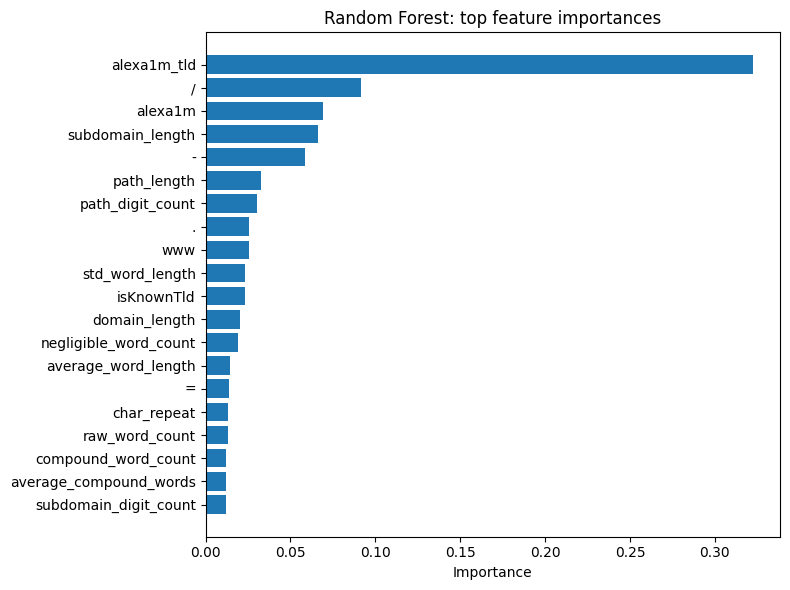


Decision Tree: top feature importances
 1. alexa1m_tld                         0.532836
 2. -                                   0.086914
 3. /                                   0.071727
 4. subdomain_digit_count               0.028399
 5. path_length                         0.024042
 6. =                                   0.022609
 7. domain_length                       0.016639
 8. path_digit_count                    0.016448
 9. www                                 0.016195
10. subdomain_length                    0.016012
11. negligible_word_count               0.015248
12. .                                   0.014495
13. average_word_length                 0.014160
14. isKnownTld                          0.012905
15. std_word_length                     0.012383
16. _                                   0.009993
17. average_compound_words              0.009883
18. shortest_word_length                0.008873
19. keyword_count                       0.008095
20. longest_word_length      

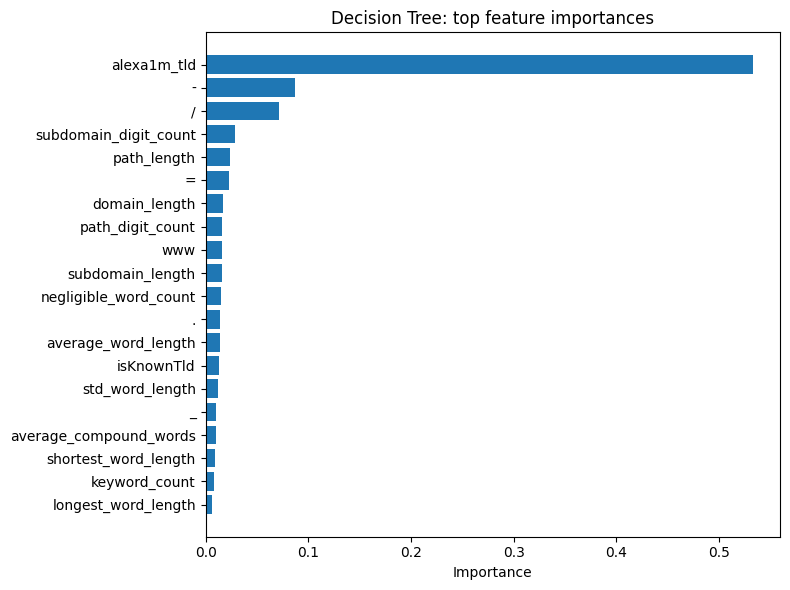


Decision Tree: top-level rules (max depth=3)
|--- alexa1m_tld <= 0.500
|   |--- - <= 2.500
|   |   |--- / <= 1.500
|   |   |   |--- www <= 0.500
|   |   |   |   |--- truncated branch of depth 24
|   |   |   |--- www >  0.500
|   |   |   |   |--- truncated branch of depth 21
|   |   |--- / >  1.500
|   |   |   |--- / <= 2.500
|   |   |   |   |--- truncated branch of depth 36
|   |   |   |--- / >  2.500
|   |   |   |   |--- truncated branch of depth 29
|   |--- - >  2.500
|   |   |--- = <= 0.500
|   |   |   |--- / <= 3.500
|   |   |   |   |--- truncated branch of depth 24
|   |   |   |--- / >  3.500
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- = >  0.500
|   |   |   |--- path_length <= 60.500
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- path_length >  60.500
|   |   |   |   |--- truncated branch of depth 5
|--- alexa1m_tld >  0.500
|   |--- subdomain_digit_count <= 0.500
|   |   |--- subdomain_length <= 8.500
|   |   |   |--- char_repeat <= 12.500


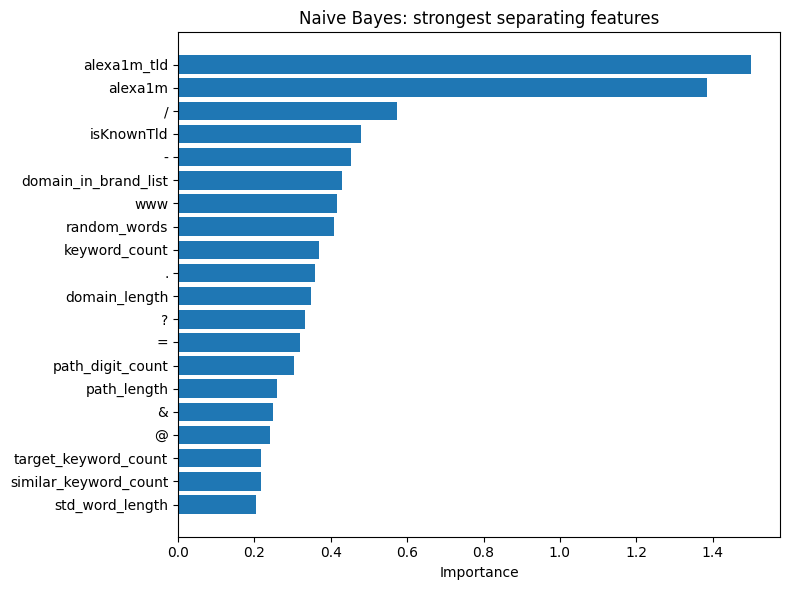


Naive Bayes: class means for top features
alexa1m_tld                         phish=0.0405 legit=0.7527
alexa1m                             phish=0.0757 legit=0.7664
/                                   phish=3.8291 legit=2.4672
isKnownTld                          phish=0.6179 legit=0.8935
-                                   phish=0.5816 legit=1.9498
domain_in_brand_list                phish=0.0017 legit=0.1596
www                                 phish=0.3011 legit=0.5860
random_words                        phish=0.7361 legit=0.2033
keyword_count                       phish=1.1047 legit=0.5372
.                                   phish=1.3248 legit=0.3887

KNN: nearest neighbors for one sample
Sample index: 0 Predicted class: phish
Neighbor class counts: {np.str_('1'): 3}
 neighbor idx= 21927 distance=0.0000 class=1
 neighbor idx=    86 distance=0.0000 class=1
 neighbor idx=     0 distance=0.0000 class=1


In [4]:
import numpy as np
from sklearn.tree import export_text
from collections import Counter
import matplotlib.pyplot as plt

# Load training data for explanations
with open(CSV_PATH, 'r', newline='') as csv_file:
    train_X, train_y = rf_runner._read_csv_dataset(csv_file, has_class=True)
train_y = np.array([str(t) for t in train_y])

def _print_top_features(scores, title, top_k=20):
    order = np.argsort(scores)[::-1][:top_k]
    print(f'\n{title}')
    for rank, idx in enumerate(order, start=1):
        print(f'{rank:2d}. {feature_names[idx]:35s} {scores[idx]:.6f}')

def _plot_top_features(scores, title, top_k=20):
    order = np.argsort(scores)[::-1][:top_k][::-1]
    plt.figure(figsize=(8, 6))
    plt.barh([feature_names[i] for i in order], [scores[i] for i in order])
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# Random Forest: global feature importance
rf_importances = rf_runner.model.feature_importances_
_print_top_features(rf_importances, 'Random Forest: top feature importances')
_plot_top_features(rf_importances, 'Random Forest: top feature importances')

# Decision Tree: global feature importance + readable rules
dt_importances = dt_runner.model.feature_importances_
_print_top_features(dt_importances, 'Decision Tree: top feature importances')
_plot_top_features(dt_importances, 'Decision Tree: top feature importances')
print('\nDecision Tree: top-level rules (max depth=3)')
print(export_text(dt_runner.model, feature_names=list(feature_names), max_depth=3, decimals=3))

# Naive Bayes: features that separate classes (mean difference / pooled std)
nb = nb_runner.model
classes = [str(c) for c in nb.classes_]
if 'phish' in classes and 'legitimate' in classes:
    idx_phish = classes.index('phish')
    idx_legit = classes.index('legitimate')
    mean_phish = nb.theta_[idx_phish]
    mean_legit = nb.theta_[idx_legit]
    var_phish = nb.var_[idx_phish]
    var_legit = nb.var_[idx_legit]
    pooled_std = np.sqrt(var_phish + var_legit + 1e-12)
    effect = np.abs(mean_phish - mean_legit) / pooled_std
    _print_top_features(effect, 'Naive Bayes: strongest separating features')
    _plot_top_features(effect, 'Naive Bayes: strongest separating features')
    top_idx = np.argsort(effect)[::-1][:10]
    print('\nNaive Bayes: class means for top features')
    for idx in top_idx:
        print(f'{feature_names[idx]:35s} phish={mean_phish[idx]:.4f} legit={mean_legit[idx]:.4f}')
else:
    print('\nNaive Bayes: class labels were', classes, "- expected 'phish' and 'legitimate'.")

# KNN: local explanation using nearest neighbors
knn = knn_runner.model
fit_X = knn._fit_X
fit_y = np.array([str(t) for t in knn._y])
sample_idx = 0
sample = fit_X[sample_idx].reshape(1, -1)
distances, indices = knn.kneighbors(sample, n_neighbors=knn.n_neighbors, return_distance=True)
pred = knn.predict(sample)[0]
neighbor_labels = [fit_y[i] for i in indices[0]]
print('\nKNN: nearest neighbors for one sample')
print('Sample index:', sample_idx, 'Predicted class:', pred)
print('Neighbor class counts:', dict(Counter(neighbor_labels)))
for dist, idx in zip(distances[0], indices[0]):
    print(f' neighbor idx={idx:6d} distance={dist:.4f} class={fit_y[idx]}')

In [5]:
import json
from collections import Counter
from pathlib import Path

input_path = Path('../input/my_phish_urls.json')
if not input_path.exists():
    raise FileNotFoundError('Could not find ../input/my_phish_urls.json')

with open(input_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

if not isinstance(test_data, list):
    raise TypeError('Expected a JSON array of URLs')

print(f'Loaded {len(test_data)} URLs from {input_path}')

model_runners = {
    'RF': rf_runner,
    'NB': nb_runner,
    'DT': dt_runner,
    'KNN': knn_runner,
}

predictions_by_model = {}
test, test_parsed_domains = rf_runner.preparing_test_data(test_data)

for model_name, runner in model_runners.items():
    model_pre, model_probability = runner.model_run(test)

    result_list = []

    for test_domain in test_parsed_domains:
        result = {}
        result['domain'] = test_domain['url']
        result['id'] = test_domain['id']
        result['predicted_class'] = model_pre[test_domain['id']]
        result['probability_phish'] = (model_probability[test_domain['id']][1] / sum(model_probability[test_domain['id']])) * 100
        result['probability_legitimate'] = (model_probability[test_domain['id']][0] / sum(model_probability[test_domain['id']])) * 100
        result_list.append(result)

    predictions_by_model[model_name] = result_list
    class_counts = Counter(item['predicted_class'] for item in result_list)

    print(f'\n=== {model_name} predictions ===')
    print('Counts:', dict(class_counts))
    print('Sample (first 5):')
    for item in result_list[:5]:
        print({
            'domain': item['domain'],
            'predicted_class': item['predicted_class'],
            'probability_phish': round(item['probability_phish'], 2),
            'probability_legitimate': round(item['probability_legitimate'], 2),
        })

2026-05-01 17:55:52,857 - INFO - domain_parser.parse_nonlabeled_samples() is running


Loaded 4140 URLs from ../input/my_phish_urls.json


100%|██████████| 4140/4140 [00:00<00:00, 45691.03it/s]
2026-05-01 17:55:52,952 - INFO - rule_extraction.extraction() is running
100%|██████████| 4140/4140 [00:16<00:00, 246.37it/s]
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished



=== RF predictions ===
Counts: {'phish': 2140, 'legitimate': 2000}
Sample (first 5):
{'domain': 'http://43.164.195.100/apps/GT_PT_09/index.html', 'predicted_class': 'phish', 'probability_phish': 90.0, 'probability_legitimate': 10.0}
{'domain': 'http://82.153.205.2', 'predicted_class': 'phish', 'probability_phish': 90.0, 'probability_legitimate': 10.0}
{'domain': 'http://82.153.205.2/control.php', 'predicted_class': 'phish', 'probability_phish': 100.0, 'probability_legitimate': 0.0}
{'domain': 'http://9674a6915d.nxcli.io/wp-content/plugins/object-cache-pro/src/Clients/Concerns/Dkb2026/DKB_new/', 'predicted_class': 'legitimate', 'probability_phish': 50.0, 'probability_legitimate': 50.0}
{'domain': 'http://account-verificate.iceiy.com/', 'predicted_class': 'legitimate', 'probability_phish': 40.0, 'probability_legitimate': 60.0}

=== NB predictions ===
Counts: {'phish': 2836, 'legitimate': 1304}
Sample (first 5):
{'domain': 'http://43.164.195.100/apps/GT_PT_09/index.html', 'predicted_clas

In [6]:
import json
from collections import Counter
from pathlib import Path

input_path = Path('../input/search_urls_20260428_110323.json')
if not input_path.exists():
    raise FileNotFoundError('Could not find ../input/search_urls_20260428_110323.json')

with open(input_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

if not isinstance(test_data, list):
    raise TypeError('Expected a JSON array of URLs')

print(f'Loaded {len(test_data)} URLs from {input_path}')

model_runners = {
    'RF': rf_runner,
    'NB': nb_runner,
    'DT': dt_runner,
    'KNN': knn_runner,
}

predictions_by_model = {}
test, test_parsed_domains = rf_runner.preparing_test_data(test_data)

for model_name, runner in model_runners.items():
    model_pre, model_probability = runner.model_run(test)

    result_list = []

    for test_domain in test_parsed_domains:
        result = {}
        result['domain'] = test_domain['url']
        result['id'] = test_domain['id']
        result['predicted_class'] = model_pre[test_domain['id']]
        result['probability_phish'] = (model_probability[test_domain['id']][1] / sum(model_probability[test_domain['id']])) * 100
        result['probability_legitimate'] = (model_probability[test_domain['id']][0] / sum(model_probability[test_domain['id']])) * 100
        result_list.append(result)

    predictions_by_model[model_name] = result_list
    class_counts = Counter(item['predicted_class'] for item in result_list)

    print(f'\n=== {model_name} predictions ===')
    print('Counts:', dict(class_counts))
    print('Sample (first 5):')
    for item in result_list[:5]:
        print({
            'domain': item['domain'],
            'predicted_class': item['predicted_class'],
            'probability_phish': round(item['probability_phish'], 2),
            'probability_legitimate': round(item['probability_legitimate'], 2),
        })

2026-05-01 17:56:21,896 - INFO - domain_parser.parse_nonlabeled_samples() is running


Loaded 4694 URLs from ../input/search_urls_20260428_110323.json


100%|██████████| 4694/4694 [00:00<00:00, 61797.69it/s]
2026-05-01 17:56:21,980 - INFO - rule_extraction.extraction() is running
100%|██████████| 4694/4694 [00:35<00:00, 130.43it/s]
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished



=== RF predictions ===
Counts: {'legitimate': 4554, 'phish': 140}
Sample (first 5):
{'domain': 'https://en.wikipedia.org/wiki/Osuna,_Sevilla', 'predicted_class': 'legitimate', 'probability_phish': 0.0, 'probability_legitimate': 100.0}
{'domain': 'https://betting-insider.com/match/2077506', 'predicted_class': 'legitimate', 'probability_phish': 50.0, 'probability_legitimate': 50.0}
{'domain': 'https://betting-insider.com/match/2096039', 'predicted_class': 'legitimate', 'probability_phish': 50.0, 'probability_legitimate': 50.0}
{'domain': 'https://www.sportsmole.co.uk/football/la-liga/sevilla-vs-osasuna_game_200146.html', 'predicted_class': 'legitimate', 'probability_phish': 0.0, 'probability_legitimate': 100.0}
{'domain': 'https://www.scorebat.com/osasuna-vs-sevilla-live-stream/', 'predicted_class': 'legitimate', 'probability_phish': 0.0, 'probability_legitimate': 100.0}

=== NB predictions ===
Counts: {'legitimate': 4578, 'phish': 116}
Sample (first 5):
{'domain': 'https://en.wikipedia

## Training split 80/20 with my data

In [ ]:
from datetime import datetime
from pathlib import Path

from preprocess import Preprocessing

input_phish = Path("../input/my_phish_urls.json")
input_legit = Path("../input/search_urls_20260428_110323.json")

for dataset_path in [input_phish, input_legit]:
    if not dataset_path.exists():
        raise FileNotFoundError(f"Missing dataset: {dataset_path}")

preprocessor = Preprocessing()
args = ["_", input_phish.name, "phish", input_legit.name, "legitimate"]
parsed_domains = preprocessor.domain_parser(args)

features = preprocessor.rule_calculation.extraction(parsed_domains)
csv_str = preprocessor.json2csv_object.convert_for_train(features, "")

output_dir = Path("../output/csv")
output_dir.mkdir(parents=True, exist_ok=True)
output_csv_path = output_dir / f"new_dataset_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
output_csv_path.write_text(csv_str)
print("Saved features to:", output_csv_path)
print("Samples:", len(features))


initializing


2026-05-01 17:58:36,185 - INFO - domain_parser.parse() is running
100%|██████████| 4140/4140 [00:00<00:00, 28579.69it/s]
2026-05-01 17:58:36,426 - INFO - domain_parser.parse() is running
100%|██████████| 4694/4694 [00:00<00:00, 66989.90it/s]
2026-05-01 17:58:36,498 - INFO - Domain Parse process is done 8834 unique URLs are parsed
2026-05-01 17:58:36,500 - INFO - rule_extraction.extraction() is running
100%|██████████| 8834/8834 [00:55<00:00, 160.30it/s]

Saved features to: ../output/csv/new_dataset_20260501_175931.csv
Samples: 8834


In [40]:
import csv
from collections import Counter
from pathlib import Path
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report


output_csv_path = Path("./output/csv/gsb.csv")


if not output_csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {output_csv_path}")


def _read_csv_from_file(csv_path):
    with open(csv_path, "r", newline="") as csv_file:
        reader = csv.DictReader(csv_file)
        if not reader.fieldnames:
            return np.asarray([], dtype=np.float32), np.array([]), []

        fieldnames = list(reader.fieldnames)
        label_col = "class" if "class" in fieldnames else fieldnames[-1]
        feature_cols = [name for name in fieldnames if name != label_col]

        data = []
        labels = []
        for row in reader:
            data.append([float(row[name]) for name in feature_cols])
            labels.append(row[label_col])

    return np.asarray(data, dtype=np.float32), np.array(labels), feature_cols


X, y, feature_cols = _read_csv_from_file(output_csv_path)
print("Samples:", len(y), "Features:", len(feature_cols))
print("Class counts:", dict(Counter(y)))

if len(y) == 0:
    raise ValueError("No samples found after feature extraction.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "RF": RandomForestClassifier(n_estimators=100, random_state=40),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(random_state=40, max_depth=10),
    "KNN": KNeighborsClassifier(n_neighbors=3),
}

labels_order = ["phish", "legitimate"]
if not all(label in set(y) for label in labels_order):
    labels_order = sorted(set(y))

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    print(f"\n{name} accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=labels_order))
    print("Confusion matrix (rows=true, cols=pred):")
    print(labels_order)
    print(cm)


Samples: 10547 Features: 45
Class counts: {np.str_('legitimate'): 4637, np.str_('phish'): 5910}

RF accuracy: 0.9787
              precision    recall  f1-score   support

       phish       0.98      0.97      0.98       928
  legitimate       0.98      0.99      0.98      1182

    accuracy                           0.98      2110
   macro avg       0.98      0.98      0.98      2110
weighted avg       0.98      0.98      0.98      2110

Confusion matrix (rows=true, cols=pred):
['phish', 'legitimate']
[[1165   17]
 [  28  900]]

NB accuracy: 0.9341
              precision    recall  f1-score   support

       phish       0.94      0.91      0.92       928
  legitimate       0.93      0.95      0.94      1182

    accuracy                           0.93      2110
   macro avg       0.93      0.93      0.93      2110
weighted avg       0.93      0.93      0.93      2110

Confusion matrix (rows=true, cols=pred):
['phish', 'legitimate']
[[1127   55]
 [  84  844]]

DT accuracy: 0.9678
   


Random Forest: top feature importances
 1. path_length                         0.138999
 2. subdomain_length                    0.137969
 3. /                                   0.108681
 4. domain_in_FWB_list                  0.054058
 5. char_repeat                         0.048780
 6. negligible_word_count               0.045608
 7. raw_word_count                      0.039018
 8. cert_validity_days                  0.037543
 9. cert_san_dns                        0.035331
10. popularity1m_tld                    0.035220
11. popularity1m                        0.031401
12. cert_san_total                      0.028466
13. -                                   0.022570
14. path_digit_count                    0.022147
15. std_word_length                     0.018086
16. subdomain_digit_count               0.015875
17. average_word_length                 0.014162
18. longest_word_length                 0.012218
19. random_words                        0.012147
20. domain_length            

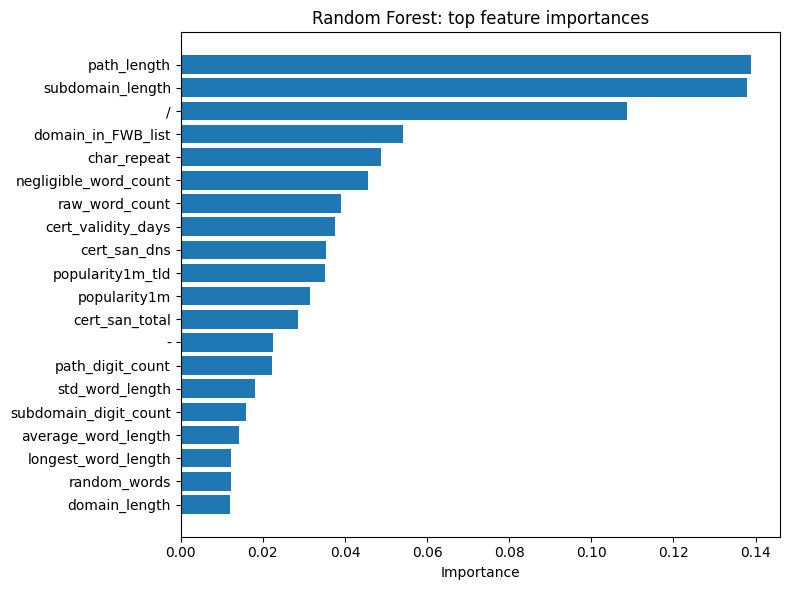


Decision Tree: top feature importances
 1. path_length                         0.583128
 2. subdomain_length                    0.153651
 3. popularity1m                        0.087491
 4. -                                   0.023946
 5. cert_validity_days                  0.020235
 6. random_words                        0.018689
 7. raw_word_count                      0.016031
 8. .                                   0.014997
 9. ?                                   0.009371
10. redirect_count                      0.006613
11. std_word_length                     0.006416
12. cert_san_total                      0.005271
13. domain_length                       0.004983
14. negligible_word_count               0.004606
15. path_digit_count                    0.004451
16. char_repeat                         0.004310
17. compound_word_count                 0.003456
18. splitted_word_count                 0.003332
19. _                                   0.003062
20. longest_word_length      

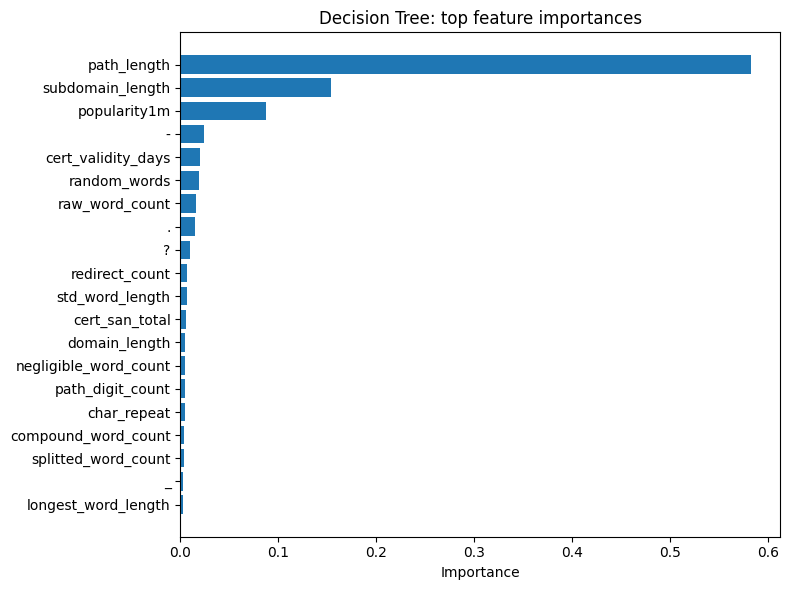


Decision Tree: top-level rules (max depth=10)
|--- path_length <= 13.500
|   |--- subdomain_length <= 3.500
|   |   |--- popularity1m <= 0.500
|   |   |   |--- cert_san_total <= 13.500
|   |   |   |   |--- char_repeat <= 2.500
|   |   |   |   |   |--- cert_validity_days <= 372.000
|   |   |   |   |   |   |--- path_length <= 11.500
|   |   |   |   |   |   |   |--- cert_san_total <= 3.500
|   |   |   |   |   |   |   |   |--- = <= 0.500
|   |   |   |   |   |   |   |   |   |--- average_word_length <= 10.250
|   |   |   |   |   |   |   |   |   |   |--- class: phish
|   |   |   |   |   |   |   |   |   |--- average_word_length >  10.250
|   |   |   |   |   |   |   |   |   |   |--- class: phish
|   |   |   |   |   |   |   |   |--- = >  0.500
|   |   |   |   |   |   |   |   |   |--- keyword_count <= 0.500
|   |   |   |   |   |   |   |   |   |   |--- class: legitimate
|   |   |   |   |   |   |   |   |   |--- keyword_count >  0.500
|   |   |   |   |   |   |   |   |   |   |--- class: phish
|   | 

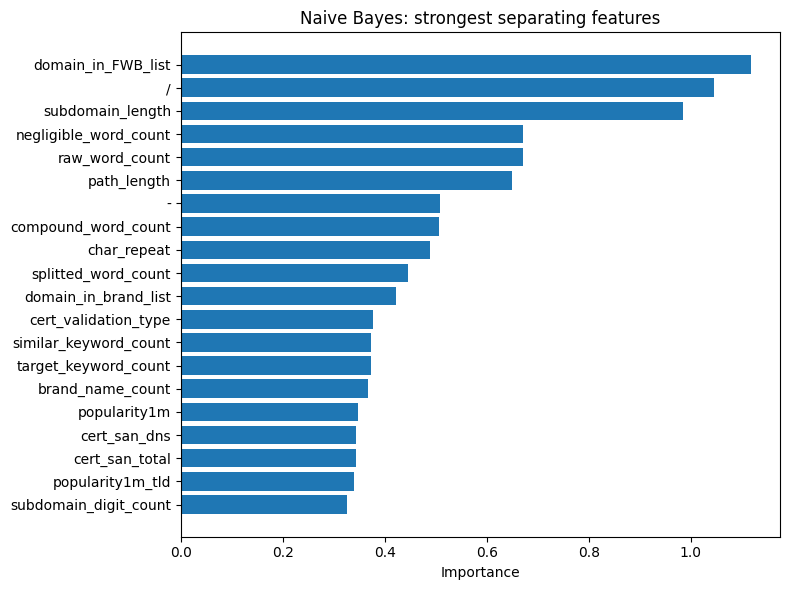


Naive Bayes: class means for top features
domain_in_FWB_list                  phish=0.5588 legit=0.0011
/                                   phish=1.2468 legit=2.9250
subdomain_length                    phish=12.4634 legit=2.5317
negligible_word_count               phish=2.6168 legit=5.2437
raw_word_count                      phish=3.2602 legit=6.2785
path_length                         phish=13.0700 legit=48.5662
-                                   phish=1.1690 legit=3.7177
compound_word_count                 phish=1.4135 legit=2.5929
char_repeat                         phish=1.2519 legit=2.8253
splitted_word_count                 phish=2.0201 legit=3.4039

KNN: nearest neighbors for one sample
Sample index: 0 Predicted class: phish
Neighbor class counts: {np.str_('1'): 2, np.str_('0'): 1}
 neighbor idx=  7424 distance=1.5811 class=1
 neighbor idx=  7526 distance=1.5811 class=1
 neighbor idx=  5586 distance=2.8284 class=0


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.tree import export_text

if "feature_cols" not in globals():
    raise NameError("Run the 80/20 training cell first to define feature_cols and models.")

if "models" not in globals():
    raise NameError("Run the 80/20 training cell first to train models.")


def _print_top_features(scores, title, top_k=20):
    order = np.argsort(scores)[::-1][:top_k]
    print(f"\n{title}")
    for rank, idx in enumerate(order, start=1):
        print(f"{rank:2d}. {feature_cols[idx]:35s} {scores[idx]:.6f}")


def _plot_top_features(scores, title, top_k=20):
    order = np.argsort(scores)[::-1][:top_k][::-1]
    plt.figure(figsize=(8, 6))
    plt.barh([feature_cols[i] for i in order], [scores[i] for i in order])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


# Random Forest: global feature importance
if "RF" in models:
    rf_importances = models["RF"].feature_importances_
    _print_top_features(rf_importances, "Random Forest: top feature importances")
    _plot_top_features(rf_importances, "Random Forest: top feature importances")

# Decision Tree: global feature importance + readable rules
if "DT" in models:
    dt_importances = models["DT"].feature_importances_
    _print_top_features(dt_importances, "Decision Tree: top feature importances")
    _plot_top_features(dt_importances, "Decision Tree: top feature importances")
    print("\nDecision Tree: top-level rules (max depth=10)")
    print(export_text(models["DT"], feature_names=list(feature_cols), max_depth=10, decimals=3))

# Naive Bayes: features that separate classes (mean difference / pooled std)
if "NB" in models:
    nb = models["NB"]
    classes = [str(c) for c in nb.classes_]
    if "phish" in classes and "legitimate" in classes:
        idx_phish = classes.index("phish")
        idx_legit = classes.index("legitimate")
        mean_phish = nb.theta_[idx_phish]
        mean_legit = nb.theta_[idx_legit]
        var_phish = nb.var_[idx_phish]
        var_legit = nb.var_[idx_legit]
        pooled_std = np.sqrt(var_phish + var_legit + 1e-12)
        effect = np.abs(mean_phish - mean_legit) / pooled_std
        _print_top_features(effect, "Naive Bayes: strongest separating features")
        _plot_top_features(effect, "Naive Bayes: strongest separating features")
        top_idx = np.argsort(effect)[::-1][:10]
        print("\nNaive Bayes: class means for top features")
        for idx in top_idx:
            print(f"{feature_cols[idx]:35s} phish={mean_phish[idx]:.4f} legit={mean_legit[idx]:.4f}")
    else:
        print("\nNaive Bayes: class labels were", classes, "- expected 'phish' and 'legitimate'.")

# KNN: local explanation using nearest neighbors
if "KNN" in models:
    knn = models["KNN"]
    if "X_test" in globals() and len(X_test) > 0:
        sample_idx = 0
        sample = X_test[sample_idx].reshape(1, -1)
        distances, indices = knn.kneighbors(sample, n_neighbors=knn.n_neighbors, return_distance=True)
        pred = knn.predict(sample)[0]
        fit_y = np.array([str(t) for t in knn._y])
        neighbor_labels = [fit_y[i] for i in indices[0]]
        print("\nKNN: nearest neighbors for one sample")
        print("Sample index:", sample_idx, "Predicted class:", pred)
        print("Neighbor class counts:", dict(Counter(neighbor_labels)))
        for dist, idx in zip(distances[0], indices[0]):
            print(f" neighbor idx={idx:6d} distance={dist:.4f} class={fit_y[idx]}")
    else:
        print("\nKNN: X_test not available or empty.")


In [36]:
import pickle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
with open('model.pkl','wb') as f:
    pickle.dump(model,f)

In [ ]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_cols,
    class_names=["legitimate", "phish"],
    discretize_continuous=True,
 )
idx = 0
pred = model.predict(X_test)[idx]
print(pred)
exp = explainer.explain_instance(X_test[idx], model.predict_proba)

for i in range(10):
    print(f"{exp.as_list()[i][0]}: {exp.as_list()[i][1]:.2f}")
from IPython.display import display, HTML
display(HTML(exp.as_html()))

phish
www <= 0.00: 0.13
0.00 < domain_in_FWB_list <= 1.00: 0.12
3.00 < subdomain_length <= 14.00: 0.11
path_length <= 4.00: 0.08
/ <= 1.00: 0.07
subdomain_digit_count <= 0.00: -0.06
cert_san_total <= 2.00: 0.05
cert_san_dns <= 2.00: 0.05
@ <= 0.00: 0.03
redirect_count <= 0.00: -0.03
